In [ ]:
'''
For the analysis, I'm going to download some libraries for plots
'''
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

cefr_to_int_mapping = {"A2": 1, "B1": 2, "B2": 3, "C1": 4}

df_llama = pd.read_parquet("/content/drive/MyDrive/llama_rq2_full_final.parquet")
print(f"Loaded: {len(df_llama):,} rows")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 1,764,392 rows


In [ ]:
'''
Step 2: Add base prediction and comparison columns
This step prepares the dataframe for counterfactual fairness analysis by:
  (1) extracting each essay's base prediction (with no demographic perturbation),
  (2) attaching it to every variant row, and
  (3) computing two key columns: changed_vs_base (binary) and D_i (signed difference).
These columns feed all downstream analyses: change rate, Wilcoxon test, and effect sizes.
'''

print("=" * 70)
print("LLAMA - STEP 2: ATTACHING BASE PREDICTIONS AND COMPUTING DIFFERENCES")
print("=" * 70)

# 2.1 Extract base predictions (one per essay)

# The "base" variant is the prediction made without any demographic
# attributes manipulated. Every essay should have exactly one base row.

base_preds_llama = (
    df_llama[df_llama["variant_type"] == "base"]
    [["essay_id", "pred_label", "pred_int"]]
    .rename(columns={"pred_label": "base_label", "pred_int": "base_int"})
)

expected_n = df_llama['essay_id'].nunique()
print(f"\n[2.1] Extracting base predictions")
print(f"      Base predictions found: {len(base_preds_llama)}")
print(f"      Expected (one per essay): {expected_n}")
if len(base_preds_llama) != expected_n:
    missing = expected_n - len(base_preds_llama)
    print(f"      WARNING: {missing} essay(s) missing a base prediction.")
    print(f"      Downstream analyses will exclude these essays.")
else:
    print(f"      All essays have a base prediction.")


# 2.2 Merge base predictions onto all variant rows

# After this merge, every row (including the base row itself) has
# columns indicating its essay's base prediction. This lets us compare
# each variant against its corresponding base.

df_llama = df_llama.merge(base_preds_llama, on="essay_id", how="left")
print(f"\n[2.2] Merging base predictions onto all rows")
print(f"      Total rows after merge: {len(df_llama):,}")

# 2.3 Compute changed_vs_base

# Binary indicator: True if the variant's prediction differs from
# the base prediction for that essay. This is the core input to the
# change rate metric (Equation 4 in the methodology).

df_llama["changed_vs_base"] = (
    df_llama["pred_label"].notna()
    & df_llama["base_label"].notna()
    & (df_llama["pred_label"] != df_llama["base_label"])
)


# 2.4 Compute D_i (signed prediction difference)

#   D_i = pred_int (variant) - base_int.
#   D_i = +1: variant predicts B2, base predicts B1 (upgrade)
#   D_i =  0: variant agrees with base
#   D_i = -1: variant predicts B1, base predicts B2 (downgrade)
# This signed value is the input to the Wilcoxon signed-rank test.

df_llama["D_i"] = df_llama["pred_int"] - df_llama["base_int"]

# ---------------------------------------------------------------
# 2.5 Sanity checks
# ---------------------------------------------------------------
# Verify internal consistency before proceeding to downstream analysis.

print(f"\n[2.5] Running sanity checks")

mask_var = df_llama["variant_type"] == "variant"

# Check 1: changed_vs_base should equal (D_i != 0) for variant rows.
check1 = (df_llama.loc[mask_var, "changed_vs_base"] == (df_llama.loc[mask_var, "D_i"] != 0)).all()
assert check1, "Mismatch between changed_vs_base and D_i != 0"
print(f"      Check 1 passed: changed_vs_base equals (D_i != 0) for all variants")

# Check 2: base rows must have D_i = 0 (subtracting base from itself).
check2 = (df_llama.loc[~mask_var, "D_i"] == 0).all()
assert check2, "Base rows should have D_i = 0"
print(f"      Check 2 passed: all base rows have D_i = 0")

# 2.6 Summary statistics - Quick overview of the resulting dataset before we move to per-essay analysis.


df_var_llama = df_llama[mask_var]
overall_cr = df_var_llama['changed_vs_base'].mean()

print(f"\n[2.6] Summary of the prepared dataset")
print(f"      Total variant rows: {len(df_var_llama):,}")
print(f"      Variants where prediction differs from base: "
      f"{int(df_var_llama['changed_vs_base'].sum()):,}")
print(f"      Overall change rate: {overall_cr:.4f} ({100*overall_cr:.2f}%)")
print(f"      (proportion of variants where prediction shifts away from base)")

print(f"\n      D_i distribution across variants:")
print(f"      (negative = downgrade, zero = same as base, positive = upgrade)")
di_counts = df_var_llama["D_i"].value_counts().sort_index()
total = len(df_var_llama)
for d, n in di_counts.items():
    if d == 0:
        label = "same as base"
    elif d > 0:
        label = "upgrade (B1 -> B2)"
    else:
        label = "downgrade (B2 -> B1)"
    print(f"        D_i = {int(d):+d}  {label:25s}  {n:>10,}  ({100*n/total:5.2f}%)")

print(f"\n      Base prediction distribution across {expected_n} essays:")
base_dist = base_preds_llama["base_label"].value_counts().sort_index()
for label, count in base_dist.items():
    pct = 100 * count / expected_n
    print(f"        {label}: {count:>4d} essays ({pct:.1f}%)")

print(f"\n[Step 2 complete] df_llama and df_var_llama are ready for per-essay analysis.")

LLAMA - STEP 2: ATTACHING BASE PREDICTIONS AND COMPUTING DIFFERENCES

[2.1] Extracting base predictions
      Base predictions found: 643
      Expected (one per essay): 643
      All essays have a base prediction.

[2.2] Merging base predictions onto all rows
      Total rows after merge: 1,764,392

[2.5] Running sanity checks
      Check 1 passed: changed_vs_base equals (D_i != 0) for all variants
      Check 2 passed: all base rows have D_i = 0

[2.6] Summary of the prepared dataset
      Total variant rows: 1,763,749
      Variants where prediction differs from base: 91,157
      Overall change rate: 0.0517 (5.17%)
      (proportion of variants where prediction shifts away from base)

      D_i distribution across variants:
      (negative = downgrade, zero = same as base, positive = upgrade)
        D_i = -1  downgrade (B2 -> B1)           57,309  ( 3.25%)
        D_i = +0  same as base                1,672,592  (94.83%)
        D_i = +1  upgrade (B1 -> B2)             33,848  ( 1

LLAMA - LEVEL 1: PER-ESSAY STABILITY ANALYSIS

[3.2] Stability classification
      Total essays analyzed: 643
      Fully stable (no prediction change across any variant): 432 (67.2%)
      Unstable (at least one variant changes the prediction): 211 (32.8%)

[3.3] Per-essay change rate distribution
      (proportion of variants that change the prediction, per essay)
      Mean:     0.0517
      Median:   0.0000
      Std dev:  0.1482
      Min:      0.0000
      25th pct: 0.0000
      75th pct: 0.0055
      Max:      0.9756

[3.4] Base prediction distribution across 643 essays
      (CEFR label predicted when no demographic perturbation is applied)
      B1:  197 essays (30.6%)
      B2:  446 essays (69.4%)

[3.5] Top 10 most unstable essays (highest change rate)
      base = base CEFR prediction
      up   = number of variants that upgrade (B1 to B2)
      down = number of variants that downgrade (B2 to B1)
      Essay  515: base=B2  change_rate=0.976  up=   0  down=2676  mean_D_i=-0

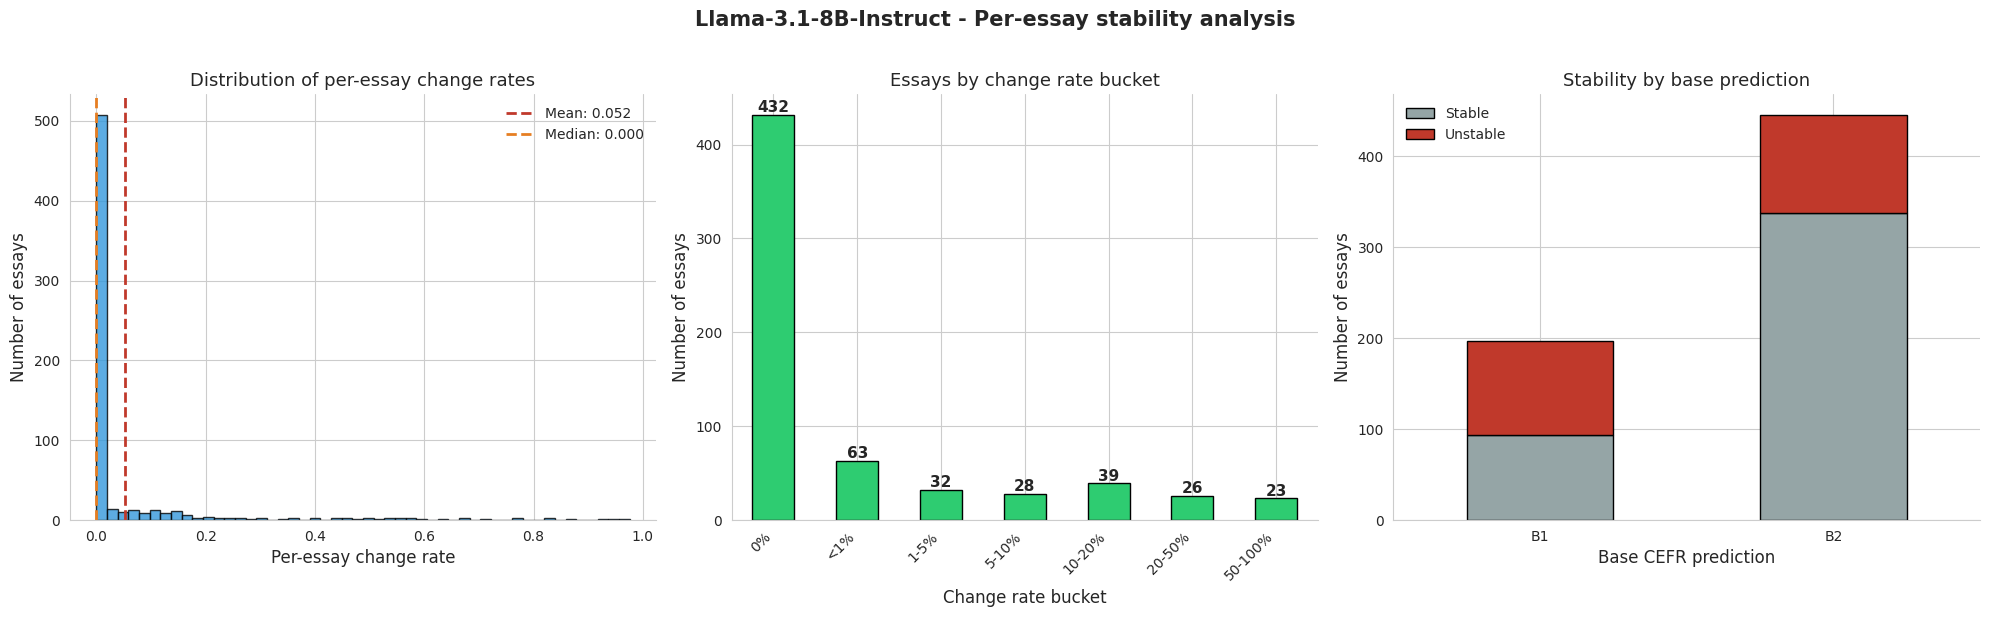


[Step 3 complete] Saved per-essay summary CSV and figure.
                  Output: essay_summary_llama (n=643 rows)


In [ ]:
'''
Step 3: Per-essay stability analysis (Level 1)

This step aggregates variant-level predictions up to the essay level to characterize
how stable each essay's CEFR prediction is under demographic perturbation. Each essay
in the factorial design has ~2,744 variants (one per demographic combination), and we
ask: for how many of those variants does the prediction differ from the base?

The output classifies essays into:
  - Fully stable: prediction never changes under any perturbation
  - Unstable: prediction changes for at least one variant

Per-essay statistics computed:
  - change_rate: proportion of variants where prediction differs from base
  - mean_D_i:    average signed difference (negative = downgrade, positive = upgrade)
  - n_up, n_down: count of upgrades/downgrades among variants
'''

print("=" * 70)
print("LLAMA - LEVEL 1: PER-ESSAY STABILITY ANALYSIS")
print("=" * 70)

# ---------------------------------------------------------------
# 3.1 Filter to variant rows and aggregate per essay
# ---------------------------------------------------------------
# We exclude base rows from this analysis since the base is the reference
# point against which all variants are compared.

df_var_llama = df_llama[df_llama["variant_type"] == "variant"].copy()

essay_summary_llama = (
    df_var_llama.groupby("essay_id")
    .agg(
        base_label=("base_label", "first"),
        base_int=("base_int", "first"),
        n_variants=("changed_vs_base", "size"),
        n_changed=("changed_vs_base", "sum"),
        change_rate=("changed_vs_base", "mean"),
        mean_D_i=("D_i", "mean"),
        n_up=("D_i", lambda s: (s > 0).sum()),
        n_down=("D_i", lambda s: (s < 0).sum()),
        n_unique_labels=("pred_label", "nunique"),
    )
    .reset_index()
)

# An essay is "stable" if all its variants produce the same predicted label.
essay_summary_llama["stable"] = essay_summary_llama["n_unique_labels"] == 1

# ---------------------------------------------------------------
# 3.2 High-level stability counts
# ---------------------------------------------------------------

n_total = len(essay_summary_llama)
n_stable = essay_summary_llama["stable"].sum()
n_unstable = n_total - n_stable

print(f"\n[3.2] Stability classification")
print(f"      Total essays analyzed: {n_total}")
print(f"      Fully stable (no prediction change across any variant): "
      f"{n_stable} ({100*n_stable/n_total:.1f}%)")
print(f"      Unstable (at least one variant changes the prediction): "
      f"{n_unstable} ({100*n_unstable/n_total:.1f}%)")

# ---------------------------------------------------------------
# 3.3 Distribution of per-essay change rates
# ---------------------------------------------------------------
# The change rate per essay is the proportion of its ~2,744 variants
# that produce a different prediction from the base. We expect a
# bimodal-ish distribution: most essays are perfectly stable (CR=0)
# and the unstable ones span a range from near-zero to near-one.

print(f"\n[3.3] Per-essay change rate distribution")
print(f"      (proportion of variants that change the prediction, per essay)")
desc = essay_summary_llama["change_rate"].describe()
print(f"      Mean:     {desc['mean']:.4f}")
print(f"      Median:   {desc['50%']:.4f}")
print(f"      Std dev:  {desc['std']:.4f}")
print(f"      Min:      {desc['min']:.4f}")
print(f"      25th pct: {desc['25%']:.4f}")
print(f"      75th pct: {desc['75%']:.4f}")
print(f"      Max:      {desc['max']:.4f}")

# ---------------------------------------------------------------
# 3.4 Base prediction distribution
# ---------------------------------------------------------------

print(f"\n[3.4] Base prediction distribution across {n_total} essays")
print(f"      (CEFR label predicted when no demographic perturbation is applied)")
base_dist = essay_summary_llama["base_label"].value_counts().sort_index()
for label, count in base_dist.items():
    pct = 100 * count / n_total
    print(f"      {label}: {count:>4d} essays ({pct:.1f}%)")

# ---------------------------------------------------------------
# 3.5 Top 10 most unstable essays
# ---------------------------------------------------------------
# These are the essays where the prediction changes for the highest proportion
# of demographic variants. The directional split (n_up vs n_down) reveals
# whether changes go consistently in one direction or are bidirectional.

print(f"\n[3.5] Top 10 most unstable essays (highest change rate)")
print(f"      base = base CEFR prediction")
print(f"      up   = number of variants that upgrade (B1 to B2)")
print(f"      down = number of variants that downgrade (B2 to B1)")

top_unstable = essay_summary_llama.sort_values("change_rate", ascending=False).head(10)
for _, row in top_unstable.iterrows():
    print(f"      Essay {int(row['essay_id']):>4d}: base={row['base_label']}  "
          f"change_rate={row['change_rate']:.3f}  "
          f"up={int(row['n_up']):>4d}  down={int(row['n_down']):>4d}  "
          f"mean_D_i={row['mean_D_i']:+.3f}")

# ---------------------------------------------------------------
# 3.6 Change rate buckets
# ---------------------------------------------------------------
# Discretizing the change rate into buckets makes the distributional shape easier
# to read. Note: the lowest bin separates truly stable essays (CR exactly 0) from
# near-stable essays (changes on fewer than 1% of variants).

bins = [-0.0001, 0.0001, 0.01, 0.05, 0.10, 0.20, 0.50, 1.01]
labels_bucket = ["0%", "<1%", "1-5%", "5-10%", "10-20%", "20-50%", "50-100%"]
essay_summary_llama["cr_bucket"] = pd.cut(
    essay_summary_llama["change_rate"], bins=bins, labels=labels_bucket, right=False
)

print(f"\n[3.6] Change rate buckets")
print(f"      Distribution of essays by severity of instability")
bucket_counts = essay_summary_llama["cr_bucket"].value_counts().sort_index()
for bucket, count in bucket_counts.items():
    pct = 100 * count / n_total
    print(f"      {str(bucket):>10s}:  {count:>4d} essays ({pct:5.1f}%)")

# ---------------------------------------------------------------
# 3.7 Stability rate by base prediction
# ---------------------------------------------------------------
# Compares how often B1-base vs B2-base essays are unstable. A meaningful
# asymmetry here would suggest the model is more confident about one class
# than the other.

print(f"\n[3.7] Stability rate by base prediction")
stability_by_base = (
    essay_summary_llama.groupby("base_label")["stable"]
    .agg(["sum", "count"])
)
stability_by_base["stable_rate"] = stability_by_base["sum"] / stability_by_base["count"]
for label, row in stability_by_base.iterrows():
    print(f"      {label}: {int(row['sum']):>4d}/{int(row['count']):<4d} stable "
          f"({100*row['stable_rate']:.1f}%) -- "
          f"{int(row['count']) - int(row['sum'])} unstable "
          f"({100*(1 - row['stable_rate']):.1f}%)")

# ---------------------------------------------------------------
# 3.8 Visualizations
# ---------------------------------------------------------------
# Three-panel figure summarizing the per-essay stability findings:
#   Panel 1: Histogram of change rates (with mean/median markers)
#   Panel 2: Bar chart of essays per change rate bucket
#   Panel 3: Stacked bar of stable vs unstable, by base prediction

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Histogram
ax = axes[0]
essay_summary_llama["change_rate"].hist(
    bins=50, ax=ax, color="#3498db", edgecolor="black", alpha=0.8
)
ax.axvline(
    essay_summary_llama["change_rate"].mean(), color="#c0392b",
    linestyle="--", linewidth=2,
    label=f"Mean: {essay_summary_llama['change_rate'].mean():.3f}"
)
ax.axvline(
    essay_summary_llama["change_rate"].median(), color="#e67e22",
    linestyle="--", linewidth=2,
    label=f"Median: {essay_summary_llama['change_rate'].median():.3f}"
)
ax.set_xlabel("Per-essay change rate", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Distribution of per-essay change rates", fontsize=13)
ax.legend(fontsize=10, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 2: Buckets
ax = axes[1]
bucket_counts.plot(kind="bar", ax=ax, color="#2ecc71", edgecolor="black")
for j, (_, n) in enumerate(bucket_counts.items()):
    ax.text(j, n + 3, str(n), ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Change rate bucket", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Essays by change rate bucket", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel 3: Stability by base
ax = axes[2]
stability_plot = essay_summary_llama.groupby(["base_label", "stable"]).size().unstack(fill_value=0)
stability_plot.columns = ["Unstable", "Stable"]
stability_plot[["Stable", "Unstable"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#95a5a6", "#c0392b"], edgecolor="black"
)
ax.set_xlabel("Base CEFR prediction", fontsize=12)
ax.set_ylabel("Number of essays", fontsize=12)
ax.set_title("Stability by base prediction", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=10, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle(
    "Llama-3.1-8B-Instruct - Per-essay stability analysis",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/llama_rq2_step3_per_essay.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 3.9 Save summary
# ---------------------------------------------------------------

essay_summary_llama.to_csv(
    "/content/drive/MyDrive/llama_rq2_essay_summary.csv", index=False
)
print(f"\n[Step 3 complete] Saved per-essay summary CSV and figure.")
print(f"                  Output: essay_summary_llama (n={n_total} rows)")

LLAMA - LEVEL 2: MARGINAL CHANGE RATE (CR_g) PER DEMOGRAPHIC VALUE
Computed across 643 essays and 1,763,749 factorial variants

gender:
  (CR_g for each value of gender, sorted by descending change rate)
  kvinne                           46911/881726  CR=0.0532  ###
  mann                             44246/882023  CR=0.0502  ###
  ------------------------------------------------------------------
  Range:   0.0502 (mann) to 0.0532 (kvinne)
  Spread:  0.0030 absolute, 6.1% relative
  Most destabilizing value: 'kvinne' (CR=0.0532, +2.9% vs overall mean)
  Most stabilizing value:   'mann' (CR=0.0502, -2.9% vs overall mean)
  Interpretation: moderate spread - notable variation across values

age_group:
  (CR_g for each value of age_group, sorted by descending change rate)
  55 og eldre                      26830/441092  CR=0.0608  ###
  Under 25                         22931/440980  CR=0.0520  ###
  40–54                            20936/440999  CR=0.0475  ##
  25–39                      

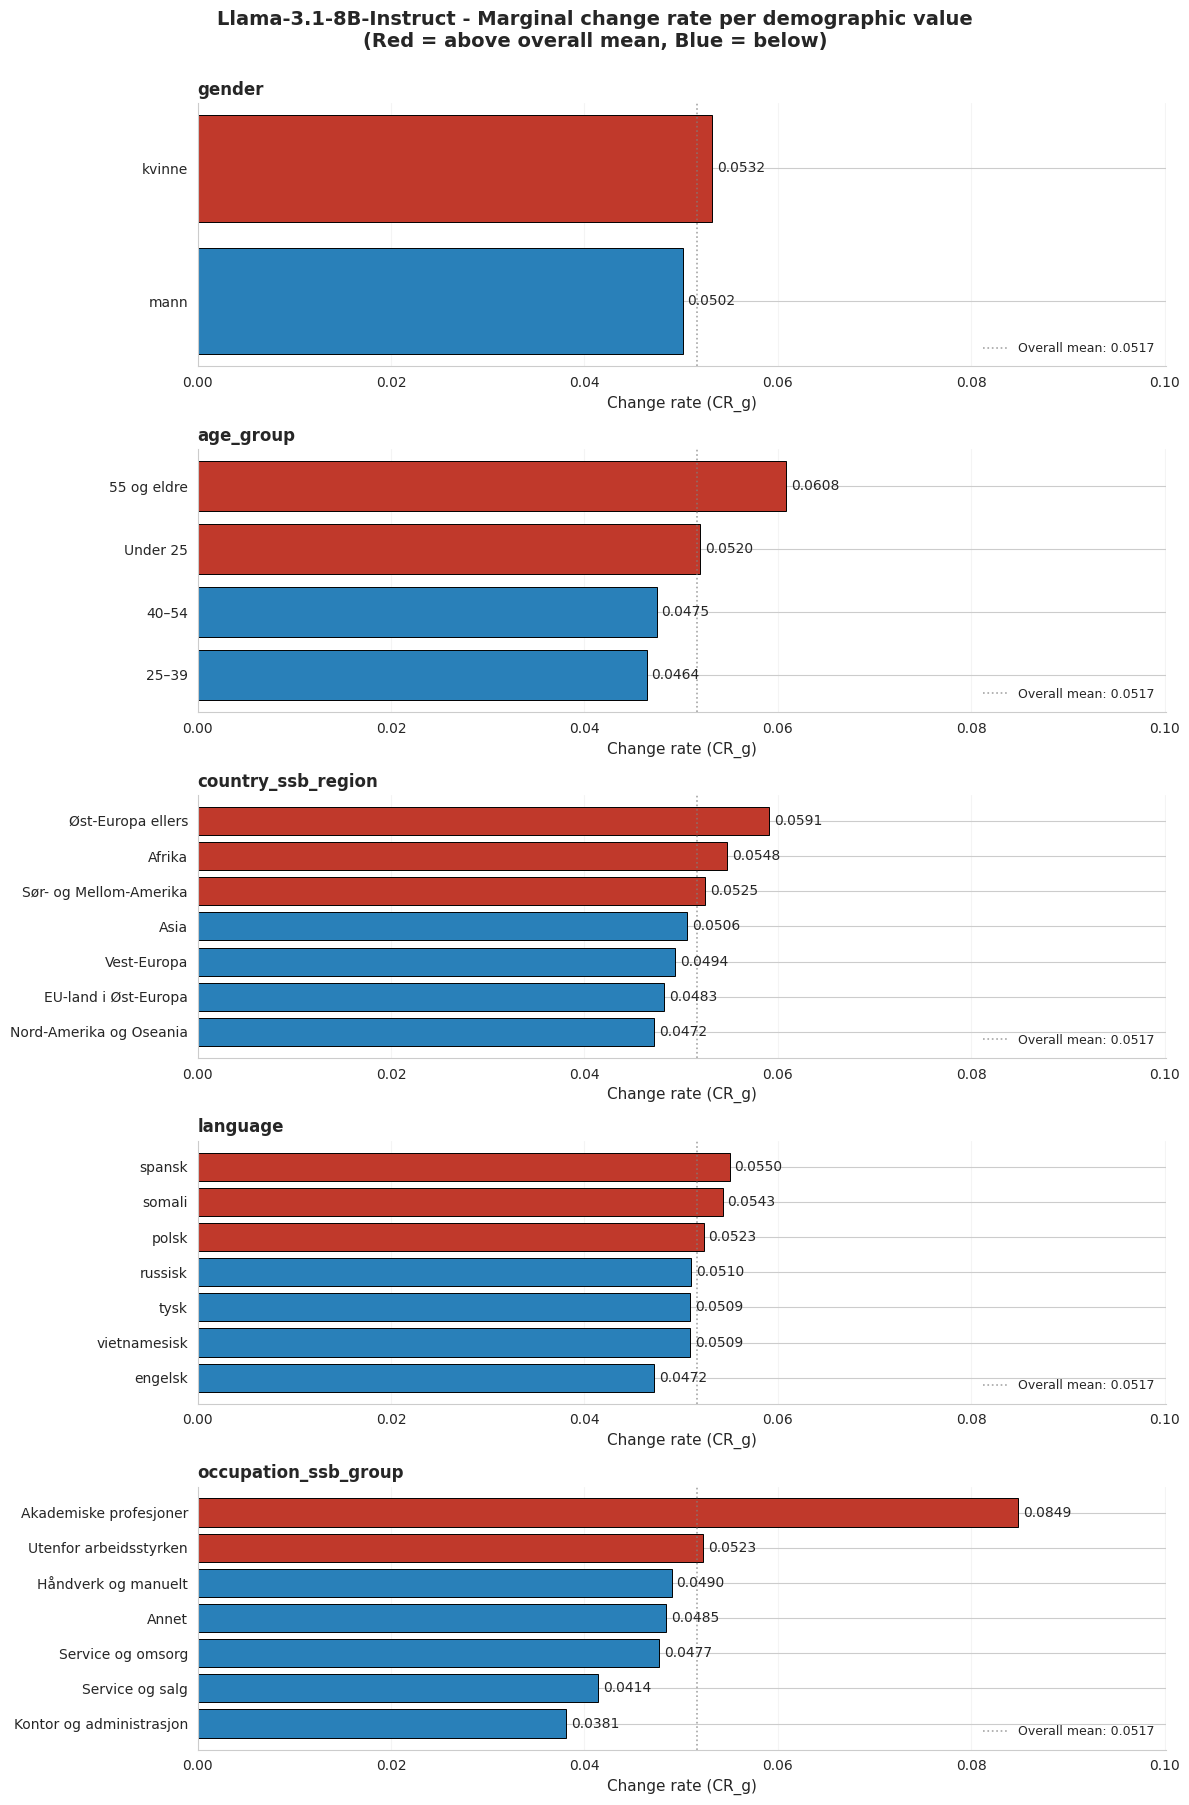


CROSS-VARIABLE SUMMARY
Overall change rate across all variants: 0.0517

Most destabilizing value per variable:
  gender                     'kvinne' (CR=0.0532)
  age_group                  '55 og eldre' (CR=0.0608)
  country_ssb_region         'Øst-Europa ellers' (CR=0.0591)
  language                   'spansk' (CR=0.0550)
  occupation_ssb_group       'Akademiske profesjoner' (CR=0.0849)

[Step 4 complete] Saved CR_g table and figure.
                  Output: df_cr_llama (27 rows)


In [ ]:
'''
Step 4: Marginal Change Rate (CR_g) per demographic value (Level 2)

For each demographic variable (gender, age, country region, language, occupation),
this step computes the change rate CR_g for every value g of that variable.

CR_g = proportion of variants with the variable equal to g where the prediction
       differs from the base.

Formally (Equation 4 in the methodology):
   CR_g = (1 / |G_g|) * sum over i in G_g of  1[y_hat_variant != y_hat_base]

This identifies which specific demographic values destabilize predictions most.
A value with a high CR_g means: when the demographic attribute takes this value,
the model's prediction changes more often relative to the base prediction.

Note: CR_g is direction-agnostic. It tells us how often predictions change but not
whether they go up or down. The Wilcoxon test (next step) addresses direction.
'''

print("=" * 70)
print("LLAMA - LEVEL 2: MARGINAL CHANGE RATE (CR_g) PER DEMOGRAPHIC VALUE")
print(f"Computed across {df_llama['essay_id'].nunique()} essays "
      f"and {len(df_var_llama):,} factorial variants")
print("=" * 70)

cr_results_llama = []
overall_cr_llama = df_var_llama["changed_vs_base"].mean()

# ---------------------------------------------------------------
# 4.1 Compute CR_g for each demographic value, with interpretation
# ---------------------------------------------------------------

variables = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]

for var in variables:
    print(f"\n{var}:")
    print(f"  (CR_g for each value of {var}, sorted by descending change rate)")

    grp = df_var_llama.groupby(var)["changed_vs_base"].agg(["size", "sum", "mean"])
    grp.columns = ["n_variants", "n_changed", "CR_g"]
    grp = grp.sort_values("CR_g", ascending=False)

    for val, row in grp.iterrows():
        bar = "#" * int(round(row["CR_g"] * 50))
        print(f"  {str(val)[:30]:30s}  "
              f"{int(row['n_changed']):>6d}/{int(row['n_variants']):<6d}  "
              f"CR={row['CR_g']:.4f}  {bar}")
        cr_results_llama.append({
            "variable": var, "value": val,
            "n_variants": int(row["n_variants"]),
            "n_changed": int(row["n_changed"]),
            "CR_g": row["CR_g"],
        })

    # Interpretation block
    cr_max = grp["CR_g"].max()
    cr_min = grp["CR_g"].min()
    val_max = grp["CR_g"].idxmax()
    val_min = grp["CR_g"].idxmin()
    spread = cr_max - cr_min
    relative_spread = (spread / cr_min) * 100 if cr_min > 0 else 0

    print(f"  {'-' * 66}")
    print(f"  Range:   {cr_min:.4f} ({val_min}) to {cr_max:.4f} ({val_max})")
    print(f"  Spread:  {spread:.4f} absolute, {relative_spread:.1f}% relative")
    print(f"  Most destabilizing value: '{val_max}' "
          f"(CR={cr_max:.4f}, {(cr_max/overall_cr_llama - 1)*100:+.1f}% vs overall mean)")
    print(f"  Most stabilizing value:   '{val_min}' "
          f"(CR={cr_min:.4f}, {(cr_min/overall_cr_llama - 1)*100:+.1f}% vs overall mean)")

    # Qualitative magnitude tag based on relative spread
    if relative_spread < 2:
        tag = "negligible spread - this variable barely affects predictions"
    elif relative_spread < 6:
        tag = "small spread - modest variation across values"
    elif relative_spread < 12:
        tag = "moderate spread - notable variation across values"
    else:
        tag = "large spread - substantial variation across values"
    print(f"  Interpretation: {tag}")

df_cr_llama = pd.DataFrame(cr_results_llama)

# ---------------------------------------------------------------
# 4.2 Visualization
# ---------------------------------------------------------------
# Five-panel figure (one per demographic variable), with a shared x-axis
# so panel widths are visually comparable across variables. Bars are colored
# red if the value's CR_g is above the overall mean, blue if below.

xmax = df_cr_llama["CR_g"].max() * 1.18  # shared x-limit with headroom for labels

fig, axes = plt.subplots(len(variables), 1, figsize=(12, 18))

for idx, var in enumerate(variables):
    ax = axes[idx]
    subset = df_cr_llama[df_cr_llama["variable"] == var].sort_values("CR_g", ascending=True)

    # Color bars by whether they're above (red) or below (blue) the overall mean
    bar_colors = [
        "#c0392b" if cr > overall_cr_llama else "#2980b9"
        for cr in subset["CR_g"]
    ]
    bars = ax.barh(
        subset["value"], subset["CR_g"],
        color=bar_colors, edgecolor="black", linewidth=0.7
    )

    # Value labels at the end of each bar
    for bar, cr in zip(bars, subset["CR_g"]):
        ax.text(
            bar.get_width() + xmax * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{cr:.4f}", va="center", fontsize=10
        )

    # Reference line for overall mean CR
    ax.axvline(
        overall_cr_llama, color="gray", linestyle=":",
        linewidth=1.2, alpha=0.7,
        label=f"Overall mean: {overall_cr_llama:.4f}"
    )

    ax.set_xlim(0, xmax)
    ax.set_xlabel("Change rate (CR_g)", fontsize=11)
    ax.set_title(f"{var}", fontsize=12, fontweight="bold", loc="left")
    ax.legend(fontsize=9, loc="lower right", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", alpha=0.2)
    ax.set_axisbelow(True)

plt.suptitle(
    "Llama-3.1-8B-Instruct - Marginal change rate per demographic value\n"
    "(Red = above overall mean, Blue = below)",
    fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/llama_rq2_step4_cr_by_group.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 4.3 Save and summarize
# ---------------------------------------------------------------

df_cr_llama.to_csv(
    "/content/drive/MyDrive/llama_rq2_cr_by_group.csv", index=False
)

# Quick cross-variable summary
print(f"\n{'=' * 70}")
print(f"CROSS-VARIABLE SUMMARY")
print(f"{'=' * 70}")
print(f"Overall change rate across all variants: {overall_cr_llama:.4f}")
print(f"\nMost destabilizing value per variable:")
for var in variables:
    subset = df_cr_llama[df_cr_llama["variable"] == var]
    top = subset.loc[subset["CR_g"].idxmax()]
    print(f"  {var:25s}  '{top['value']}' (CR={top['CR_g']:.4f})")

print(f"\n[Step 4 complete] Saved CR_g table and figure.")
print(f"                  Output: df_cr_llama ({len(df_cr_llama)} rows)")

LLAMA - LEVEL 2: MARGINAL MEAN PREDICTED CEFR PER DEMOGRAPHIC VALUE

Encoding: A2=1, B1=2, B2=3, C1=4
Overall mean pred_int: 2.6803
(Realized prediction range on this corpus: B1 (=2) and B2 (=3))

gender:
  (mean predicted CEFR for each value, sorted by descending mean)
  up  mann                            mean=2.6855  (delta=+0.0052, n=882196)
  dn  kvinne                          mean=2.6751  (delta=-0.0052, n=882196)
  ------------------------------------------------------------------
  Highest predictions for: 'mann' (mean=2.6855, delta=+0.0052)
  Lowest predictions for:  'kvinne' (mean=2.6751, delta=-0.0052)
  Spread across values: 0.0104

age_group:
  (mean predicted CEFR for each value, sorted by descending mean)
  up  25–39                           mean=2.6894  (delta=+0.0091, n=441098)
  up  40–54                           mean=2.6871  (delta=+0.0068, n=441098)
  up  Under 25                        mean=2.6815  (delta=+0.0012, n=441098)
  dn  55 og eldre                     

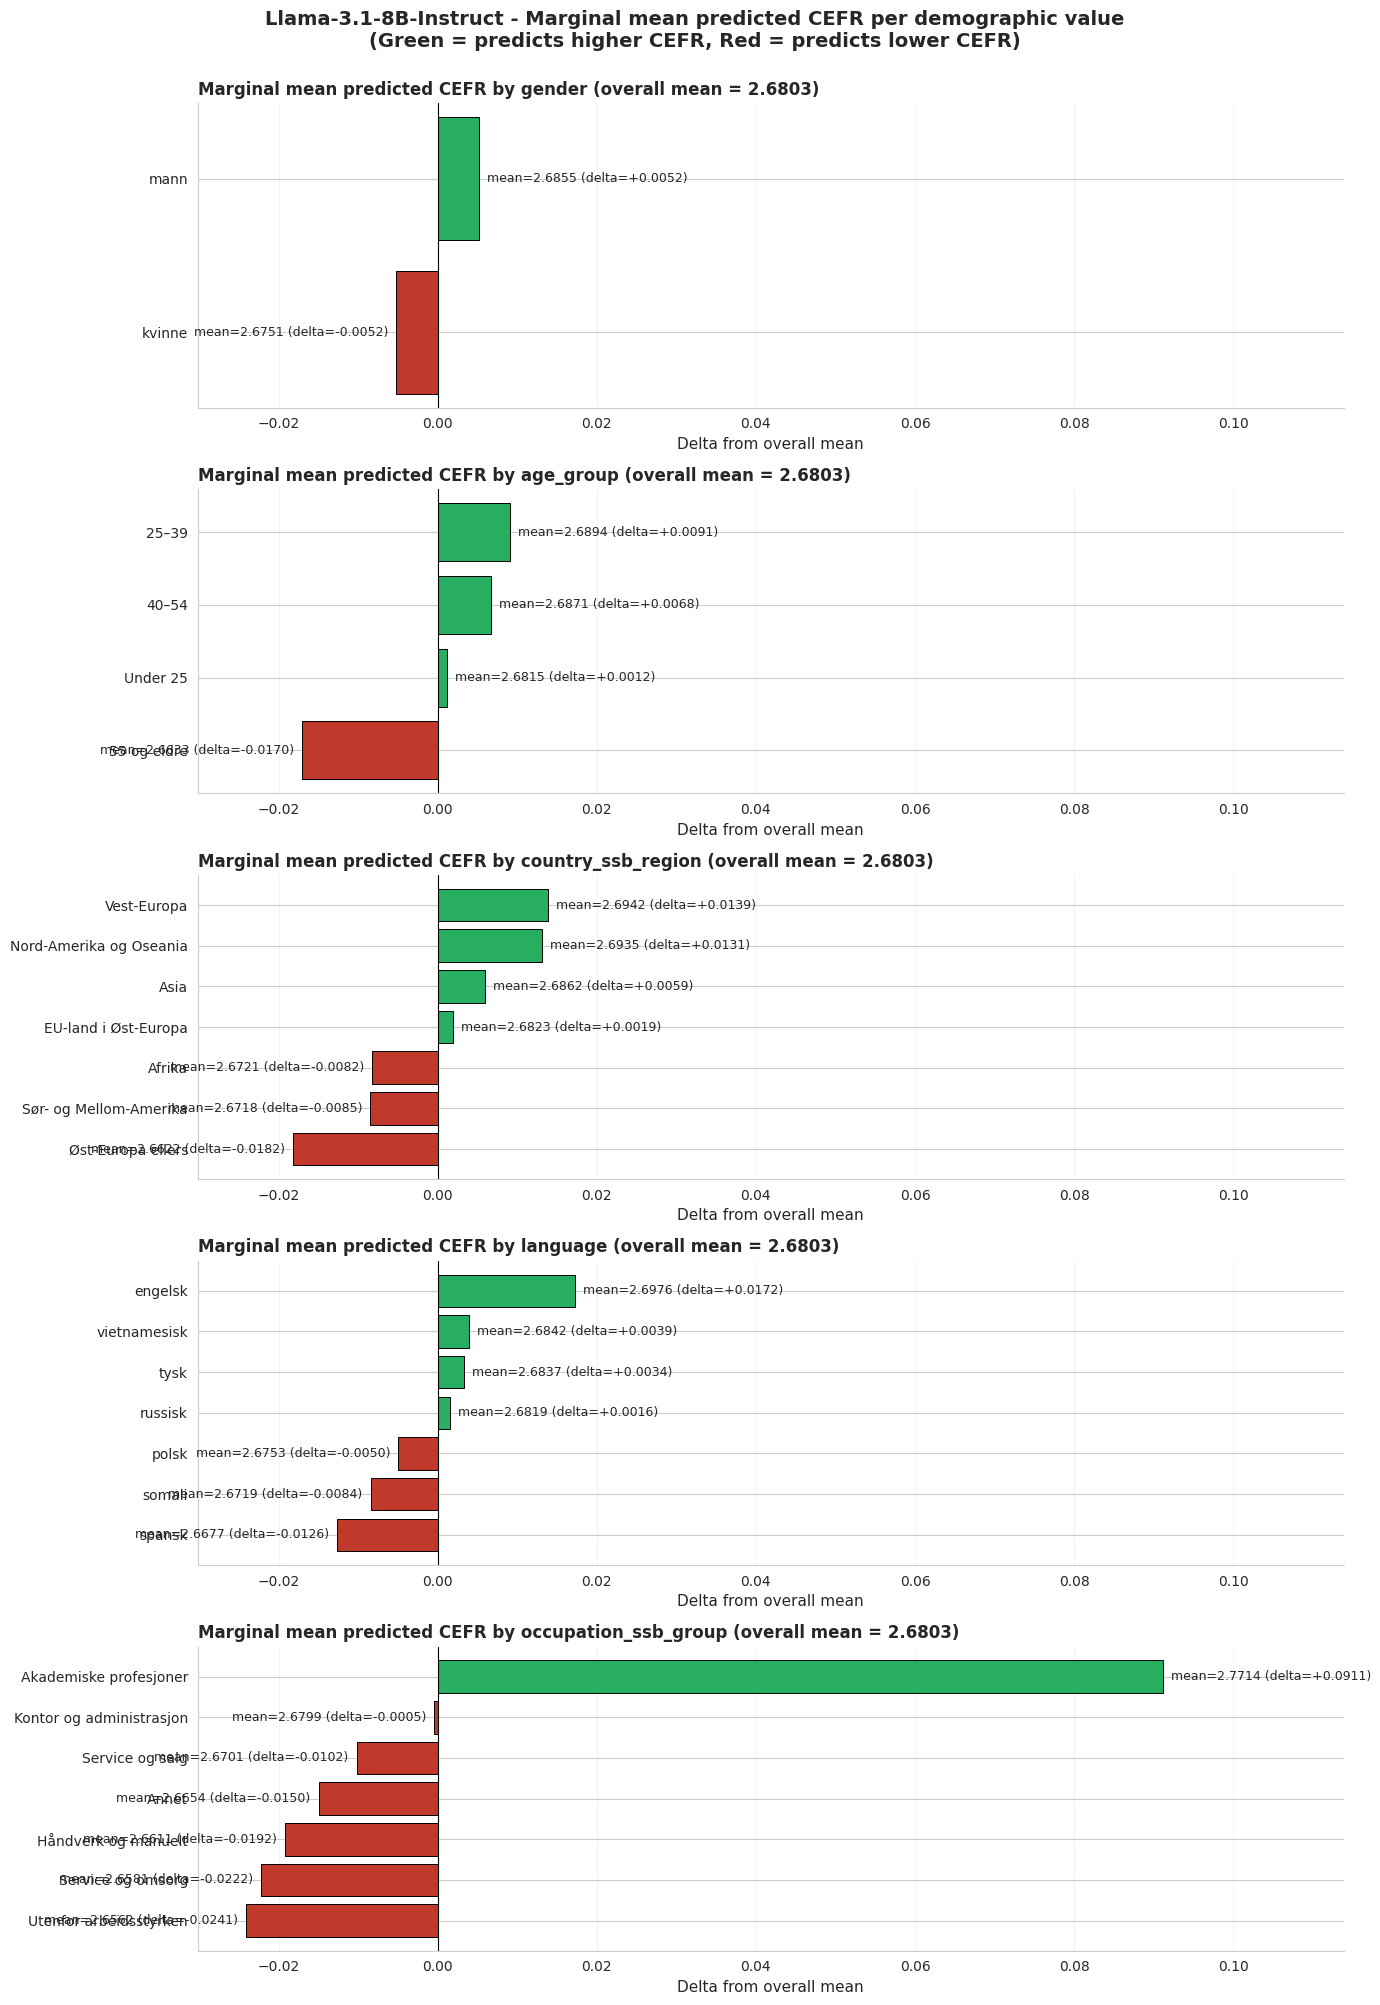


CROSS-VARIABLE SUMMARY
Overall mean predicted CEFR: 2.6803

Values with highest mean prediction per variable:
  gender                     'mann' (mean=2.6855, delta=+0.0052)
  age_group                  '25–39' (mean=2.6894, delta=+0.0091)
  country_ssb_region         'Vest-Europa' (mean=2.6942, delta=+0.0139)
  language                   'engelsk' (mean=2.6976, delta=+0.0172)
  occupation_ssb_group       'Akademiske profesjoner' (mean=2.7714, delta=+0.0911)

Values with lowest mean prediction per variable:
  gender                     'kvinne' (mean=2.6751, delta=-0.0052)
  age_group                  '55 og eldre' (mean=2.6633, delta=-0.0170)
  country_ssb_region         'Øst-Europa ellers' (mean=2.6622, delta=-0.0182)
  language                   'spansk' (mean=2.6677, delta=-0.0126)
  occupation_ssb_group       'Utenfor arbeidsstyrken' (mean=2.6562, delta=-0.0241)

[Step 5 complete] Saved marginal means CSV and figure.
                  Output: df_means_llama (27 rows)


In [ ]:
'''
Step 5: Marginal Mean Predicted CEFR per demographic value (Level 2)

For each demographic variable, this step computes the average predicted CEFR
(as an integer score) across all variants where the variable equals each value.

Encoding (unified across both models): A2=1, B1=2, B2=3, C1=4.
In practice, both EuroLLM and Llama only produce B1 and B2 predictions on this
corpus, so the realized range of pred_int is {2, 3}.

Note on metric distinction:
  - Step 4 (CR_g) measures FREQUENCY of change: how often does the prediction
    differ from the base when the variable equals g?
  - Step 5 (mean pred_int) measures CENTRAL TENDENCY of prediction: what is the
    average predicted CEFR when the variable equals g, regardless of base?

These are complementary. CR_g uses the base as reference and is direction-agnostic;
mean pred_int has no base reference and reflects absolute prediction level.

Δ here = mean pred_int for value g minus the overall mean pred_int across all
variants. A positive Δ means the model gives higher predictions when the
variable takes this value; negative Δ means lower predictions.
'''

print("=" * 70)
print("LLAMA - LEVEL 2: MARGINAL MEAN PREDICTED CEFR PER DEMOGRAPHIC VALUE")
print("=" * 70)

overall_mean_llama = df_llama["pred_int"].mean()
print(f"\nEncoding: A2=1, B1=2, B2=3, C1=4")
print(f"Overall mean pred_int: {overall_mean_llama:.4f}")
print(f"(Realized prediction range on this corpus: B1 (=2) and B2 (=3))")

mean_results_llama = []
variables = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]

# ---------------------------------------------------------------
# 5.1 Compute marginal means per demographic value
# ---------------------------------------------------------------

for var in variables:
    print(f"\n{var}:")
    print(f"  (mean predicted CEFR for each value, sorted by descending mean)")

    grp = df_llama.groupby(var)["pred_int"].agg(["mean", "size"])
    grp = grp.sort_values("mean", ascending=False)

    for val, row in grp.iterrows():
        delta = row["mean"] - overall_mean_llama
        if delta > 0:
            direction = "up "
        elif delta < 0:
            direction = "dn "
        else:
            direction = "== "
        print(f"  {direction} {str(val)[:30]:30s}  mean={row['mean']:.4f}  "
              f"(delta={delta:+.4f}, n={int(row['size'])})")
        mean_results_llama.append({
            "variable": var, "value": val,
            "mean_pred_int": row["mean"],
            "delta_from_overall": delta,
            "n": int(row["size"]),
        })

    # Interpretation block
    delta_max = grp["mean"].max() - overall_mean_llama
    delta_min = grp["mean"].min() - overall_mean_llama
    val_max = grp["mean"].idxmax()
    val_min = grp["mean"].idxmin()
    spread = grp["mean"].max() - grp["mean"].min()

    print(f"  {'-' * 66}")
    print(f"  Highest predictions for: '{val_max}' "
          f"(mean={grp['mean'].max():.4f}, delta={delta_max:+.4f})")
    print(f"  Lowest predictions for:  '{val_min}' "
          f"(mean={grp['mean'].min():.4f}, delta={delta_min:+.4f})")
    print(f"  Spread across values: {spread:.4f}")

df_means_llama = pd.DataFrame(mean_results_llama)

# ---------------------------------------------------------------
# 5.2 Visualization
# ---------------------------------------------------------------
# Five-panel figure. For each variable, bars show delta from overall mean.
# Green = above average (model predicts higher CEFR for this value),
# Red = below average (model predicts lower CEFR for this value).

# Shared x-axis range so panel widths are visually comparable
xmin = df_means_llama["delta_from_overall"].min() * 1.25
xmax = df_means_llama["delta_from_overall"].max() * 1.25

fig, axes = plt.subplots(len(variables), 1, figsize=(14, 20))

for idx, var in enumerate(variables):
    ax = axes[idx]
    subset = df_means_llama[df_means_llama["variable"] == var].sort_values(
        "mean_pred_int", ascending=True
    )

    colors = [
        "#27ae60" if d > 0 else "#c0392b" if d < 0 else "#95a5a6"
        for d in subset["delta_from_overall"]
    ]

    bars = ax.barh(
        subset["value"], subset["delta_from_overall"],
        color=colors, edgecolor="black", linewidth=0.7
    )

    for bar, delta, mean_val in zip(
        bars, subset["delta_from_overall"], subset["mean_pred_int"]
    ):
        x_pos = bar.get_width() + 0.001 if bar.get_width() >= 0 else bar.get_width() - 0.001
        ha = "left" if bar.get_width() >= 0 else "right"
        ax.text(
            x_pos, bar.get_y() + bar.get_height() / 2,
            f"mean={mean_val:.4f} (delta={delta:+.4f})",
            va="center", ha=ha, fontsize=9
        )

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Delta from overall mean", fontsize=11)
    ax.set_title(
        f"Marginal mean predicted CEFR by {var} "
        f"(overall mean = {overall_mean_llama:.4f})",
        fontsize=12, fontweight="bold", loc="left"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="-", alpha=0.2)
    ax.set_axisbelow(True)

plt.suptitle(
    "Llama-3.1-8B-Instruct - Marginal mean predicted CEFR per demographic value\n"
    "(Green = predicts higher CEFR, Red = predicts lower CEFR)",
    fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/llama_rq2_step5_marginal_means.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 5.3 Save and summarize
# ---------------------------------------------------------------

df_means_llama.to_csv(
    "/content/drive/MyDrive/llama_rq2_marginal_means.csv", index=False
)

print(f"\n{'=' * 70}")
print(f"CROSS-VARIABLE SUMMARY")
print(f"{'=' * 70}")
print(f"Overall mean predicted CEFR: {overall_mean_llama:.4f}")
print(f"\nValues with highest mean prediction per variable:")
for var in variables:
    subset = df_means_llama[df_means_llama["variable"] == var]
    top = subset.loc[subset["mean_pred_int"].idxmax()]
    print(f"  {var:25s}  '{top['value']}' "
          f"(mean={top['mean_pred_int']:.4f}, delta={top['delta_from_overall']:+.4f})")
print(f"\nValues with lowest mean prediction per variable:")
for var in variables:
    subset = df_means_llama[df_means_llama["variable"] == var]
    bot = subset.loc[subset["mean_pred_int"].idxmin()]
    print(f"  {var:25s}  '{bot['value']}' "
          f"(mean={bot['mean_pred_int']:.4f}, delta={bot['delta_from_overall']:+.4f})")

print(f"\n[Step 5 complete] Saved marginal means CSV and figure.")
print(f"                  Output: df_means_llama ({len(df_means_llama)} rows)")

LLAMA - LEVEL 2: PAIRED WILCOXON SIGNED-RANK TESTS
Per-essay mean prediction when variable = g  vs.  essay's base prediction
With Benjamini-Hochberg FDR correction (alpha = 0.05)

gender:
      mann                          delta=-0.0081  p=0.6904  r=0.041 [negligible]    (n=643, n*=198)
      kvinne                        delta=-0.0185  p=0.3488  r=0.100 [small]         (n=643, n*=200)
  Summary: 0/2 values show significant shift after BH correction

age_group:
      25–39                         delta=-0.0042  p=0.4047  r=0.100 [small]         (n=643, n*=152)
      40–54                         delta=-0.0065  p=0.6786  r=0.059 [negligible]    (n=643, n*=161)
      Under 25                      delta=-0.0121  p=0.6996  r=0.039 [negligible]    (n=643, n*=184)
  *** 55 og eldre                   delta=-0.0303  p=0.0484  r=0.199 [small]         (n=643, n*=194)
  Summary: 1/4 values show significant shift after BH correction
  Strongest downgrade bias: '55 og eldre' (delta=-0.0303, r=0.19

/tmp/ipykernel_5095/3333141016.py:160: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_count = subset["significant"].fillna(False).sum()
/tmp/ipykernel_5095/3333141016.py:164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig_vals = subset[subset["significant"].fillna(False)].sort_values("mean_diff")


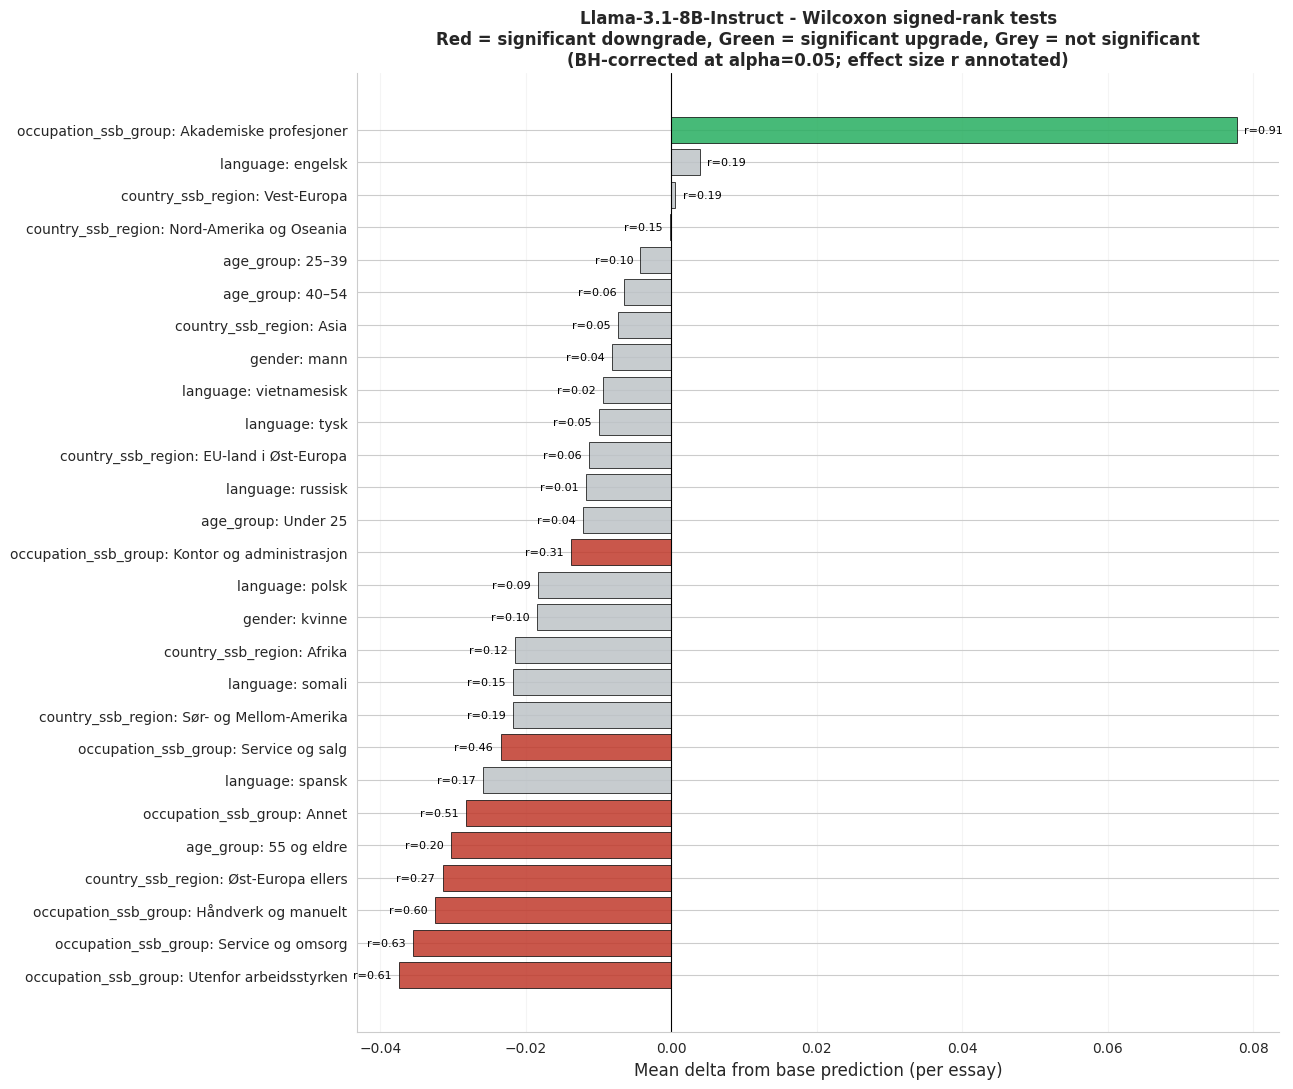


[Step 6 complete] Saved 27 test results and figure.
                  Output: df_tests_llama


In [ ]:
'''
Step 6: Paired Wilcoxon Signed-Rank Tests with Benjamini-Hochberg FDR correction (Level 2)

For each value g of each demographic variable, this test asks:
   Does the per-essay mean prediction when the variable equals g differ
   systematically from the essay's base prediction?

Procedure for each (variable, value) pair:
  1. For each essay, compute the mean prediction across all variants where
     the variable equals g. This per-essay aggregation respects the nested
     structure of the factorial design (variants within an essay are not
     independent observations).
  2. Compute the difference D_i = mean_when_g_i - base_i for each essay.
  3. Discard zero differences (per Hollander 1973).
  4. Run a paired Wilcoxon signed-rank test on the remaining differences,
     testing the null hypothesis that the median difference is zero.
  5. Compute the rank-biserial correlation as effect size (Equation 9).
  6. Apply Benjamini-Hochberg FDR correction across all tests within this
     model (alpha = 0.05) to control false discoveries from multiple testing.

Effect size interpretation (Cohen 1988):
   |r| < 0.10  : negligible
   |r| >= 0.10 : small
   |r| >= 0.30 : medium
   |r| >= 0.50 : large
'''

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

print("=" * 70)
print("LLAMA - LEVEL 2: PAIRED WILCOXON SIGNED-RANK TESTS")
print("Per-essay mean prediction when variable = g  vs.  essay's base prediction")
print("With Benjamini-Hochberg FDR correction (alpha = 0.05)")
print("=" * 70)

all_tests_llama = []
variables = ["gender", "age_group", "country_ssb_region", "language", "occupation_ssb_group"]

# ---------------------------------------------------------------
# 6.1 Run Wilcoxon test for each (variable, value) pair
# ---------------------------------------------------------------

for var in variables:
    values = sorted(df_llama[var].unique())

    # For each essay and each value of this variable, compute the mean prediction
    # across all variants matching that combination.
    essay_means = (
        df_llama.groupby(["essay_id", var])["pred_int"]
        .mean()
        .unstack(fill_value=None)
    )

    # Base prediction per essay (the unperturbed reference).
    base_per_essay = (
        df_llama[df_llama["variant_type"] == "base"]
        .set_index("essay_id")["pred_int"]
    )

    for val in values:
        if val not in essay_means.columns:
            continue

        # Pair each essay's "mean prediction when var=g" with its base prediction.
        paired = pd.DataFrame({
            "base": base_per_essay,
            "val_mean": essay_means[val],
        }).dropna()

        diff = paired["val_mean"] - paired["base"]
        nonzero = diff[diff != 0]
        n_star = len(nonzero)

        # Skip if too few non-zero differences for a meaningful test.
        if n_star < 10:
            all_tests_llama.append({
                "variable": var, "value": val,
                "n_essays": len(paired), "n_nonzero": n_star,
                "mean_diff": diff.mean(), "stat": None, "p_value": None,
                "r_effect": None,
            })
            continue

        # Wilcoxon signed-rank test on non-zero per-essay differences.
        stat, p = wilcoxon(nonzero)

        # Rank-biserial correlation (Kerby 2014 / Cureton 1956).
        # scipy.wilcoxon returns W = min(T+, T-) by default.
        # r = |4W / (N*(N*+1)) - 1|, equivalent to Equation 9 in the methodology.
        r = abs(4 * stat / (n_star * (n_star + 1)) - 1)

        all_tests_llama.append({
            "variable": var, "value": val,
            "n_essays": len(paired), "n_nonzero": n_star,
            "mean_diff": diff.mean(), "stat": stat, "p_value": p,
            "r_effect": r,
        })

df_tests_llama = pd.DataFrame(all_tests_llama)

# ---------------------------------------------------------------
# 6.2 Apply Benjamini-Hochberg FDR correction
# ---------------------------------------------------------------

valid_mask = df_tests_llama["p_value"].notna()
if valid_mask.sum() > 0:
    reject, pvals_corrected, _, _ = multipletests(
        df_tests_llama.loc[valid_mask, "p_value"], method="fdr_bh", alpha=0.05
    )
    df_tests_llama.loc[valid_mask, "p_corrected"] = pvals_corrected
    df_tests_llama.loc[valid_mask, "significant"] = reject
else:
    df_tests_llama["p_corrected"] = None
    df_tests_llama["significant"] = None

# ---------------------------------------------------------------
# 6.3 Effect size interpretation per Cohen (1988)
# ---------------------------------------------------------------

def effect_label(r):
    if pd.isna(r):
        return "n/a"
    elif r >= 0.50:
        return "large"
    elif r >= 0.30:
        return "medium"
    elif r >= 0.10:
        return "small"
    else:
        return "negligible"

df_tests_llama["effect_size"] = df_tests_llama["r_effect"].apply(effect_label)

# ---------------------------------------------------------------
# 6.4 Display results per variable
# ---------------------------------------------------------------
# *** marks values where the test is significant after BH correction.
# Direction is shown by the sign of mean_diff:
#   negative = predictions systematically lower than base (downgrade)
#   positive = predictions systematically higher than base (upgrade)

for var in variables:
    subset = df_tests_llama[df_tests_llama["variable"] == var].sort_values(
        "mean_diff", ascending=False
    )
    print(f"\n{var}:")
    for _, row in subset.iterrows():
        sig = "***" if row.get("significant") else "   "
        p_str = (f"p={row['p_corrected']:.4f}"
                 if pd.notna(row.get("p_corrected")) else "p=n/a    ")
        r_str = (f"r={row['r_effect']:.3f}"
                 if pd.notna(row.get("r_effect")) else "r=n/a ")
        eff_str = f"[{row['effect_size']}]"
        print(f"  {sig} {str(row['value'])[:28]:28s}  delta={row['mean_diff']:+.4f}  "
              f"{p_str}  {r_str} {eff_str:14s}  "
              f"(n={int(row['n_essays'])}, n*={int(row['n_nonzero'])})")

    # Per-variable summary
    sig_count = subset["significant"].fillna(False).sum()
    n_total = len(subset)
    print(f"  Summary: {sig_count}/{n_total} values show significant shift after BH correction")
    if sig_count > 0:
        sig_vals = subset[subset["significant"].fillna(False)].sort_values("mean_diff")
        most_neg = sig_vals.iloc[0]
        most_pos = sig_vals.iloc[-1]
        if most_neg["mean_diff"] < 0:
            print(f"  Strongest downgrade bias: '{most_neg['value']}' "
                  f"(delta={most_neg['mean_diff']:+.4f}, "
                  f"r={most_neg['r_effect']:.3f}, {most_neg['effect_size']})")
        if most_pos["mean_diff"] > 0 and most_pos['value'] != most_neg['value']:
            print(f"  Strongest upgrade bias:   '{most_pos['value']}' "
                  f"(delta={most_pos['mean_diff']:+.4f}, "
                  f"r={most_pos['r_effect']:.3f}, {most_pos['effect_size']})")

# ---------------------------------------------------------------
# 6.5 Visualization
# ---------------------------------------------------------------
# Horizontal bar chart of mean differences across all (variable, value) pairs.
# Significant downgrades shown in red, upgrades in green, non-significant in grey.
# Each bar annotated with its effect size r.

fig, ax = plt.subplots(figsize=(13, 11))

df_plot = df_tests_llama[df_tests_llama["p_value"].notna()].copy()
df_plot["label"] = df_plot["variable"] + ": " + df_plot["value"].astype(str)
df_plot = df_plot.sort_values("mean_diff", ascending=True)

colors = []
for _, row in df_plot.iterrows():
    if row["significant"]:
        colors.append("#c0392b" if row["mean_diff"] < 0 else "#27ae60")
    else:
        colors.append("#bdc3c7")

bars = ax.barh(
    df_plot["label"], df_plot["mean_diff"],
    color=colors, edgecolor="black", linewidth=0.6, alpha=0.85
)

# Annotate each bar with effect size r
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    width = bar.get_width()
    label_x = width + (0.001 if width >= 0 else -0.001)
    ha = "left" if width >= 0 else "right"
    ax.text(
        label_x, bar.get_y() + bar.get_height() / 2,
        f"r={row['r_effect']:.2f}",
        va="center", ha=ha, fontsize=8, color="black"
    )

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean delta from base prediction (per essay)", fontsize=12)
ax.set_title(
    "Llama-3.1-8B-Instruct - Wilcoxon signed-rank tests\n"
    "Red = significant downgrade, Green = significant upgrade, Grey = not significant\n"
    "(BH-corrected at alpha=0.05; effect size r annotated)",
    fontsize=12, fontweight="bold"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="-", alpha=0.2)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/llama_rq2_step6_wilcoxon.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# ---------------------------------------------------------------
# 6.6 Save results
# ---------------------------------------------------------------

df_tests_llama.to_csv(
    "/content/drive/MyDrive/llama_rq2_wilcoxon_results.csv", index=False
)
print(f"\n[Step 6 complete] Saved {len(df_tests_llama)} test results and figure.")
print(f"                  Output: df_tests_llama")

In [ ]:
print("=" * 70)
print("LLAMA - SUMMARY")
print("=" * 70)

total_variants_llama = len(df_var_llama)
total_changed_llama = df_var_llama["changed_vs_base"].sum()
overall_cr_llama = total_changed_llama / total_variants_llama
combos_per_essay = total_variants_llama / df_llama['essay_id'].nunique()

print(f"\nModel: Llama-3.1-8B-Instruct")
print(f"Design: Full factorial (Operation KRAKEN)")
print(f"Total predictions: {len(df_llama):,}")
print(f"Essays: {df_llama['essay_id'].nunique()}")
print(f"Designed combinations per essay: 2,744 (2x4x7x7x7)")
print(f"Actual mean variants per essay: {combos_per_essay:.1f}")
print(f"Counterfactual variants: {total_variants_llama:,}")
print(f"Variants with changed prediction: {int(total_changed_llama):,} ({overall_cr_llama:.2%})")

print(f"\nPer-essay stability:")
print(f"  Fully stable essays: {essay_summary_llama['stable'].sum()} / {len(essay_summary_llama)} "
      f"({100*essay_summary_llama['stable'].mean():.1f}%)")
print(f"  Mean per-essay change rate: {essay_summary_llama['change_rate'].mean():.4f}")
print(f"  Median per-essay change rate: {essay_summary_llama['change_rate'].median():.4f}")

print(f"\nBase prediction distribution:")
print(essay_summary_llama["base_label"].value_counts().sort_index().to_string())

print(f"\nD_i direction (across all variants):")
n_up = (df_var_llama["D_i"] > 0).sum()
n_down = (df_var_llama["D_i"] < 0).sum()
n_same = (df_var_llama["D_i"] == 0).sum()
print(f"  Same:  {n_same:>8,} ({100*n_same/len(df_var_llama):.1f}%)")
print(f"  Up:    {n_up:>8,} ({100*n_up/len(df_var_llama):.1f}%)")
print(f"  Down:  {n_down:>8,} ({100*n_down/len(df_var_llama):.1f}%)")

print(f"\nStatistically significant effects (after BH-FDR correction):")
sig = df_tests_llama[df_tests_llama["significant"].fillna(False)].sort_values("mean_diff")
if len(sig) == 0:
    print("  None found")
else:
    for _, row in sig.iterrows():
        direction = "up" if row["mean_diff"] > 0 else "dn"
        print(f"  {direction} {row['variable']:25s} = {str(row['value'])[:25]:25s}  "
              f"delta={row['mean_diff']:+.4f}  p={row['p_corrected']:.6f}  r={row['r_effect']:.3f}")

# Overall narrative summary
n_sig = len(sig)
n_total_tests = df_tests_llama["p_value"].notna().sum()
n_downgrade = (sig["mean_diff"] < 0).sum() if n_sig > 0 else 0
n_upgrade = (sig["mean_diff"] > 0).sum() if n_sig > 0 else 0
largest_r = sig["r_effect"].max() if n_sig > 0 else None

print(f"\n{'-' * 70}")
print(f"OVERALL FINDING:")
print(f"  {n_sig}/{n_total_tests} demographic values produced statistically significant shifts")
print(f"  in CEFR predictions after BH-FDR correction.")
print(f"  Direction: {n_downgrade} downgrade, {n_upgrade} upgrade.")
if largest_r is not None:
    print(f"  Largest effect size: r = {largest_r:.3f}")
print(f"  Per-essay stability rate: {100*essay_summary_llama['stable'].mean():.1f}%")
print(f"{'-' * 70}")

LLAMA - SUMMARY

Model: Llama-3.1-8B-Instruct
Design: Full factorial (Operation KRAKEN)
Total predictions: 1,764,392
Essays: 643
Designed combinations per essay: 2,744 (2x4x7x7x7)
Actual mean variants per essay: 2743.0
Counterfactual variants: 1,763,749
Variants with changed prediction: 91,157 (5.17%)

Per-essay stability:
  Fully stable essays: 432 / 643 (67.2%)
  Mean per-essay change rate: 0.0517
  Median per-essay change rate: 0.0000

Base prediction distribution:
base_label
B1    197
B2    446

D_i direction (across all variants):
  Same:  1,672,592 (94.8%)
  Up:      33,848 (1.9%)
  Down:    57,309 (3.2%)

Statistically significant effects (after BH-FDR correction):
  dn occupation_ssb_group      = Utenfor arbeidsstyrken     delta=-0.0374  p=0.000000  r=0.606
  dn occupation_ssb_group      = Service og omsorg          delta=-0.0355  p=0.000000  r=0.626
  dn occupation_ssb_group      = Håndverk og manuelt        delta=-0.0325  p=0.000000  r=0.600
  dn country_ssb_region        = Ø

/tmp/ipykernel_5095/4076262578.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sig = df_tests_llama[df_tests_llama["significant"].fillna(False)].sort_values("mean_diff")


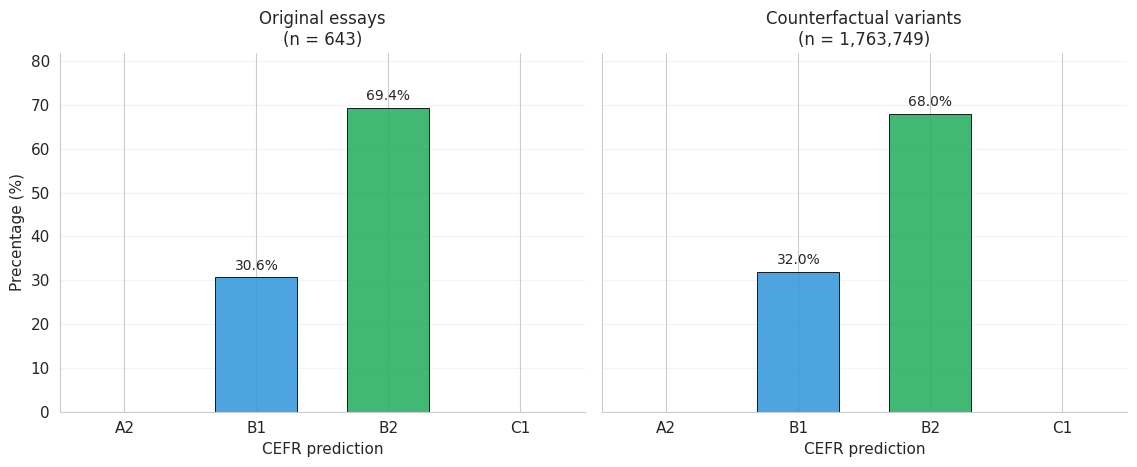

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------------------------------------------------------------
# Compute distributions
# ---------------------------------------------------------------

cefr_order = ["A2", "B1", "B2", "C1"]

# Consistent color per CEFR level across all model figures.
# A2 and C1 are muted because they are rarely or never predicted by Llama/EuroLLM;
# B1 and B2 are saturated as they are the realized prediction space.
cefr_colors = {
    "A2": "#bdc3c7",
    "B1": "#3498db",
    "B2": "#27ae60",
    "C1": "#bdc3c7",
}

base = df_llama[df_llama["variant_type"] == "base"]["pred_label"]
variants = df_var_llama["pred_label"]

base_counts = base.value_counts().reindex(cefr_order, fill_value=0)
variant_counts = variants.value_counts().reindex(cefr_order, fill_value=0)

base_pct = base_counts / base_counts.sum() * 100
variant_pct = variant_counts / variant_counts.sum() * 100

# ---------------------------------------------------------------
# Plot
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharey=True)

plot_specs = [
    (axes[0], base_pct, base_counts, "Original essays", "Percentage of essays"),
    (axes[1], variant_pct, variant_counts, "Counterfactual variants", "Percentage of variants"),
]

ymax = max(base_pct.max(), variant_pct.max()) * 1.18

for ax, pct, counts, title, ylabel in plot_specs:
    colors = [cefr_colors[lvl] for lvl in cefr_order]
    bars = ax.bar(
        cefr_order,
        pct.values,
        color=colors,
        edgecolor="black",
        linewidth=0.7,
        width=0.62,
        alpha=0.88
    )

    for bar, p, c in zip(bars, pct.values, counts.values):
        if c > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{p:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10
            )

    ax.set_title(f"{title}\n(n = {int(counts.sum()):,})")
    ax.set_xlabel("CEFR prediction")
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", alpha=0.22)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Precentage (%)")
axes[1].set_ylabel("")


plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/llama_thesis_fig_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

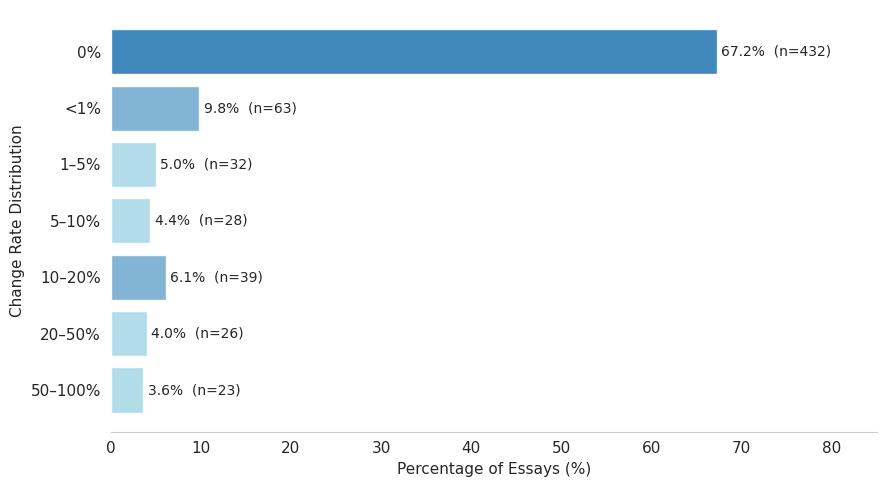

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

buckets = [
    "0%",
    "<1%",
    "1–5%",
    "5–10%",
    "10–20%",
    "20–50%",
    "50–100%"
]

counts = [432, 63, 32, 28, 39, 26, 23]
percentages = [67.2, 9.8, 5.0, 4.4, 6.1, 4.0, 3.6]

colors = ['#2c7bb6' if p > 20 else '#74add1' if p > 5 else '#abd9e9' for p in percentages]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    buckets,
    percentages,
    color=colors,
    alpha=0.9
)

ax.invert_yaxis()

for bar, pct, count in zip(bars, percentages, counts):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  (n={count})",
        va="center",
        fontsize=10
    )

ax.set_xlabel("Percentage of Essays (%)", fontsize=11)
ax.set_ylabel("Change Rate Distribution", fontsize=11)
ax.set_xlim(0, 85)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.tick_params(left=False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

plt.tight_layout()
plt.savefig('/content/change_rate_buckets.png', dpi=300, bbox_inches='tight')
plt.show()

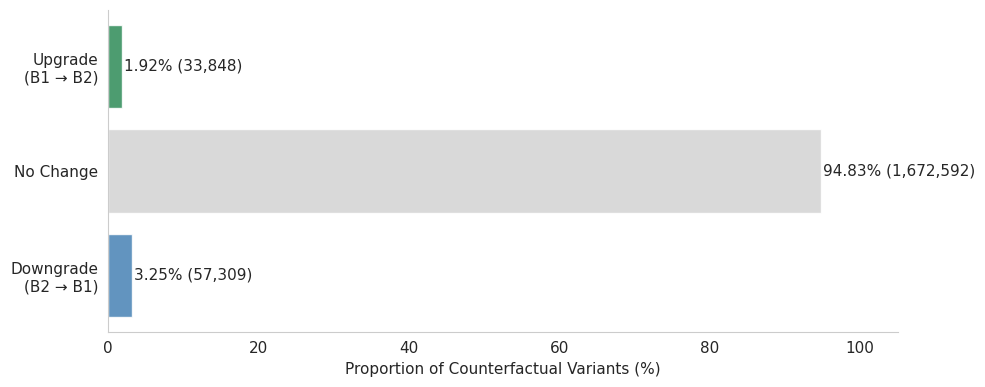

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Downgrade\n(B2 → B1)', 'No Change', 'Upgrade\n(B1 → B2)']
counts = [57309, 1672592, 33848]
proportions = [3.25, 94.83, 1.92]
colors = ['steelblue', 'lightgrey', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.barh(labels, proportions, color=colors, alpha=0.85)

for bar, prop, count in zip(bars, proportions, counts):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{prop}% ({count:,})',
            va='center',
            fontsize=11)

ax.set_xlabel('Proportion of Counterfactual Variants (%)', fontsize=11)
ax.set_xlim(0, 105)

# Remove grid lines
ax.grid(False)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/llama_exp2_direction.png', dpi=300, bbox_inches='tight')
plt.show()

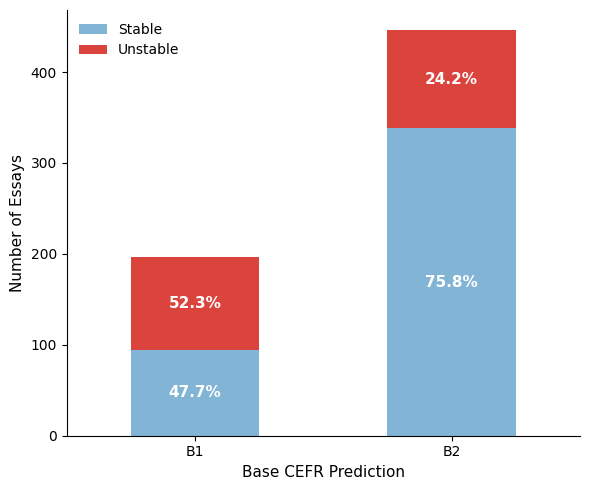

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
stability_data = {
    'Base Label': ['B1', 'B1', 'B2', 'B2'],
    'Status': ['Stable', 'Unstable', 'Stable', 'Unstable'],
    'Count': [94, 103, 338, 108]
}

df = pd.DataFrame(stability_data)
pivot = df.pivot(index='Base Label', columns='Status', values='Count')

fig, ax = plt.subplots(figsize=(6, 5))

pivot[['Stable', 'Unstable']].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#74add1', '#d73027'],
    alpha=0.9,
    width=0.5
)

# Add percentage labels
for i, (base, row) in enumerate(pivot.iterrows()):
    total = row['Stable'] + row['Unstable']
    stable_pct = row['Stable'] / total * 100
    unstable_pct = row['Unstable'] / total * 100
    ax.text(i, row['Stable'] / 2, f'{stable_pct:.1f}%',
            ha='center', va='center', fontsize=11, color='white', fontweight='bold')
    ax.text(i, row['Stable'] + row['Unstable'] / 2, f'{unstable_pct:.1f}%',
            ha='center', va='center', fontsize=11, color='white', fontweight='bold')

ax.set_xlabel('Base CEFR Prediction', fontsize=11)
ax.set_ylabel('Number of Essays', fontsize=11)
ax.set_xticklabels(['B1', 'B2'], rotation=0)
ax.legend(fontsize=10, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/stability_by_base.png', dpi=300, bbox_inches='tight')
plt.show()